# OSC variant scoring

Score ClinVar noncoding variants with AlphaGenome, then compare pathogenic/likely pathogenic (P/LP) vs benign/likely benign (B/LB) scores and visualize a single variant's predicted REF vs ALT tracks.

## Contents

1. Environment and imports
2. Paths, gene interval, and annotation
3. AlphaGenome API client
4. Convert VCF/BED to CSV
5. Batch score variants
6. Active-allele scorers
7. Load and summarize ClinVar scores
8. Visualize a single variant
9. Heart-filtered score export

## Environment and imports

Load the OSC conda/CUDA modules, then import AlphaGenome, pandas, and helpers. API keys are read from `.env` (`AG_API_KEY_*`).

In [1]:
%%bash
module load miniconda3/24.1.2-py310
module load cuda/12.4.1
conda activate py311

In [2]:
from alphagenome.models import dna_client, variant_scorers
from alphagenome.data import gene_annotation, genome, transcript, track_data
from alphagenome.visualization import plot_components
import pandas as pd
import os
from pathlib import Path
from tqdm import tqdm
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
load_dotenv(dotenv_path=".env")
API_KEYS = [v for _, v in sorted(
    ((k, os.environ[k].strip()) for k in os.environ
     if k.startswith("AG_API_KEY_") and k.removeprefix("AG_API_KEY_").isdigit()),
    key=lambda kv: int(kv[0].removeprefix("AG_API_KEY_")),
) if v]

## Paths, gene interval, and annotation

LMNA coordinates on chr1, local hg38/GENCODE paths, and UBERON ontology terms for heart (`UBERON:0000948`) and left ventricle (`UBERON:0002084`). The GTF feather file is loaded here for later transcript plots.

Calibration scores (used if a local model is initialized): https://storage.googleapis.com/alphagenome/data/hg38/calibration_scores.pb

In [3]:
LMNA_START = 156_082_572
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_082_572, 156_140_081)

BASE_PATH = '/users/PAS2905/coraalbers/'

AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'
CALIBRATION_PATH = f'{AG_DATA_PATH}calibration_scores.pb'

CLINVAR_PATH = '/users/PAS2905/coraalbers/ag/clinvar.vcf.gz'

HEART_UB = 'UBERON:0000948'
LV_UB = 'UBERON:0002084'

gtf = pd.read_feather(
    HG38_GTF_PATH
)

## AlphaGenome API client

Create the AlphaGenome DNA client from `API_KEYS[4]`. Batch scoring and single-variant plots use this same `model` object.

In [3]:
model = dna_client.create(API_KEYS[4])

print('API model initialized!')

API model initialized!


## ClinVar inputs

Pathogenic/likely pathogenic (P/LP) and benign/likely benign (B/LB) ClinVar variants were extracted in the `clinvar_variant_extraction` notebook. VCFs from that notebook are the inputs here.

## Convert VCF/BED to CSV

Read a VCF-like BED (`blb_with_nc.bed`), assign chromosome `chr1`, and write a CSV. This is a one-off conversion; batch scoring below currently loads `clinvar_cardio_noncoding.tsv` instead.

In [5]:
def get_vcf_names(vcf_path):
    """Finds the true column header line inside the VCF file."""
    with open(vcf_path, "r") as f:
        for line in f:
            if line.startswith("#CHROM"):
                # Remove the leading '#' and split by tabs
                return line.strip("#").strip().split("\t")
    raise ValueError("No header line starting with '#CHROM' found.")


vcf_filename = f'{BASE_PATH}ag/variant-effects/osc/outputs/blb_with_nc.bed'
csv_filename = f'{BASE_PATH}ag/variant-effects/osc/outputs/blb_with_nc.csv'

column_names = ['CHROM', 'POS', 'ID', 'REF','ALT', 'QUAL', 'FILTER', 'INFO', 'NC_CHROM', 'NC_START', 'NC_END', 'BP_OVERLAP']

# Read the VCF file, skipping metadata rows starting with '##'
df = pd.read_csv(
    vcf_filename,
    comment="#",
    sep="\t",
    names=column_names,
    header=None,
    low_memory=False,
    index_col=False
)



In [6]:
df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,NC_CHROM,NC_START,NC_END,BP_OVERLAP
0,1,156114771,1245553,C,A,.,.,ALLELEID=1234223;CLNDISDB=MedGen:C3661900;CLND...,1,156081998,156114918,1
1,1,156114772,1291232,C,A,.,.,ALLELEID=1281051;CLNDISDB=MedGen:C3661900;CLND...,1,156081998,156114918,1
2,1,156114791,292829,T,C,.,.,AF_TGP=0.0008;ALLELEID=277441;CLNDISDB=.|MONDO...,1,156081998,156114918,1
3,1,156114821,1269019,G,C,.,.,ALLELEID=1261450;CLNDISDB=MedGen:C3661900;CLND...,1,156081998,156114918,1
4,1,156114831,292831,G,T,.,.,AF_TGP=0.02196;ALLELEID=277446;CLNDISDB=.|Huma...,1,156081998,156114918,1
...,...,...,...,...,...,...,...,...,...,...,...,...
194,1,156138478,1380476,C,A,.,.,ALLELEID=1421298;CLNDISDB=MedGen:CN230736|EFO:...,1,156137761,156138487,1
195,1,156138479,924728,C,T,.,.,AF_EXAC=0.0001;ALLELEID=915226;CLNDISDB=MONDO:...,1,156137761,156138487,1
196,1,156138480,918676,C,T,.,.,ALLELEID=915118;CLNDISDB=Human_Phenotype_Ontol...,1,156137761,156138487,1
197,1,156138484,4781680,C,G,.,.,"ALLELEID=4893206;CLNDISDB=MONDO:MONDO:0018993,...",1,156137761,156138487,1


In [7]:
df['CHROM'] = 'chr1'
df

# Export the clean structure to a CSV
df.to_csv(csv_filename, index=False)
print(f"Successfully exported genomic VCF data to {csv_filename}!")

Successfully exported genomic VCF data to /users/PAS2905/coraalbers/ag/variant-effects/osc/outputs/blb_with_nc.csv!


## Batch score variants

Load `clinvar_cardio_noncoding.tsv`, choose sequence length (1 MB) and recommended scorers, then score each variant with the AlphaGenome API. Per-scorer CSVs are written under `outputs/clinvar_scores_from_noncoding_python_script/`.

Adapted from the [AlphaGenome batch variant scoring Colab](https://www.alphagenomedocs.com/colabs/batch_variant_scoring.html). 

In [33]:
csv_file = f'{BASE_PATH}ag/variant-effects/osc/outputs/clinvar_cardio_noncoding.tsv'
vcf = pd.read_csv(csv_file, sep='\t')
vcf = vcf.rename(columns={"variant_id": "ID", 
                    "chromosome": "CHROM",
                   'position': 'POS',
                    'ref': 'REF',
                    'alt': 'ALT'
                   })
print(vcf.columns)
required_columns = ['ID', 'CHROM', 'POS', 'REF', 'ALT']
for column in required_columns:
  if column not in vcf.columns:
    raise ValueError(f'VCF file is missing required column: {column}.')

organism = 'human'  # @param ["human", "mouse"] {type:"string"}

# @markdown Specify length of sequence around variants to predict:
sequence_length = '1MB'  # @param ["16KB", "100KB", "500KB", "1MB"] { type:"string" }
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{sequence_length}'
]


# @markdown Specify which scorers to use to score your variants:
score_rna_seq = True  # @param { type: "boolean"}
score_cage = True  # @param { type: "boolean" }
score_procap = True  # @param { type: "boolean" }
score_atac = True  # @param { type: "boolean" }
score_dnase = True  # @param { type: "boolean" }
score_chip_histone = True  # @param { type: "boolean" }
score_chip_tf = True  # @param { type: "boolean" }
score_polyadenylation = False  # @param { type: "boolean" }
score_splice_sites = True  # @param { type: "boolean" }
score_splice_site_usage = True  # @param { type: "boolean" }
score_splice_junctions = True  # @param { type: "boolean" }



# Parse organism specification.
organism_map = {
    'human': dna_client.Organism.HOMO_SAPIENS,
    'mouse': dna_client.Organism.MUS_MUSCULUS,
}
organism = organism_map[organism]

# Parse scorer specification.
scorer_selections = {
    'rna_seq': score_rna_seq,
    'cage': score_cage,
    'procap': score_procap,
    'atac': score_atac,
    'dnase': score_dnase,
    'chip_histone': score_chip_histone,
    'chip_tf': score_chip_tf,
    'polyadenylation': score_polyadenylation,
    'splice_sites': score_splice_sites,
    'splice_site_usage': score_splice_site_usage,
    'splice_junctions': score_splice_junctions,
}

all_scorers = variant_scorers.RECOMMENDED_VARIANT_SCORERS
# print(all_scorers)
selected_scorers = [
    all_scorers[key]
    for key in all_scorers
    if scorer_selections.get(key.lower(), False)
]



# Remove any scorers or output types that are not supported for the chosen organism.
unsupported_scorers = [
    scorer
    for scorer in selected_scorers
    if (
        organism.value
        not in variant_scorers.SUPPORTED_ORGANISMS[scorer.base_variant_scorer]
    )
    | (
        (scorer.requested_output == dna_client.OutputType.PROCAP)
        & (organism == dna_client.Organism.MUS_MUSCULUS)
    )
]
if len(unsupported_scorers) > 0:
  print(
      f'Excluding {unsupported_scorers} scorers as they are not supported for'
      f' {organism}.'
  )
  for unsupported_scorer in unsupported_scorers:
    selected_scorers.remove(unsupported_scorer)

print(*selected_scorers, sep='\n')



Index(['ID', 'CHROM', 'POS', 'REF', 'ALT', 'clinical_significance',
       'variant_location', 'condition', 'gene_symbol', 'allele_id',
       'variation_id', 'review_stars', 'rs_id', 'hgvs_name'],
      dtype='object')
CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)
CenterMaskScorer(requested_output=DNASE, width=501, aggregation_type=DIFF_LOG2_SUM)
CenterMaskScorer(requested_output=CHIP_TF, width=501, aggregation_type=DIFF_LOG2_SUM)
CenterMaskScorer(requested_output=CHIP_HISTONE, width=2001, aggregation_type=DIFF_LOG2_SUM)
CenterMaskScorer(requested_output=CAGE, width=501, aggregation_type=DIFF_LOG2_SUM)
CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=DIFF_LOG2_SUM)
GeneMaskLFCScorer(requested_output=RNA_SEQ)
GeneMaskSplicingScorer(requested_output=SPLICE_SITES, width=None)
GeneMaskSplicingScorer(requested_output=SPLICE_SITE_USAGE, width=None)
SpliceJunctionScorer()


In [30]:
variant_scorers.RECOMMENDED_VARIANT_SCORERS.keys()


dict_keys(['ATAC', 'CONTACT_MAPS', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'PROCAP', 'RNA_SEQ', 'RNA_SEQ_ACTIVE', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'POLYADENYLATION', 'ATAC_ACTIVE', 'DNASE_ACTIVE', 'CHIP_TF_ACTIVE', 'CHIP_HISTONE_ACTIVE', 'CAGE_ACTIVE', 'PROCAP_ACTIVE'])

In [39]:
all_scorers = variant_scorers.RECOMMENDED_VARIANT_SCORERS
scorer_titles = ['ATAC', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'PROCAP', 'RNA_SEQ', 'RNA_SEQ_ACTIVE', 'ATAC_ACTIVE', 'DNASE_ACTIVE', 'CHIP_TF_ACTIVE', 'CHIP_HISTONE_ACTIVE', 'CAGE_ACTIVE', 'PROCAP_ACTIVE', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS']

# print(*all_scorers, sep='\n')
for key, value in all_scorers.items():
    print(f"{key}: {value}")

ATAC: CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)
CONTACT_MAPS: ContactMapScorer()
DNASE: CenterMaskScorer(requested_output=DNASE, width=501, aggregation_type=DIFF_LOG2_SUM)
CHIP_TF: CenterMaskScorer(requested_output=CHIP_TF, width=501, aggregation_type=DIFF_LOG2_SUM)
CHIP_HISTONE: CenterMaskScorer(requested_output=CHIP_HISTONE, width=2001, aggregation_type=DIFF_LOG2_SUM)
CAGE: CenterMaskScorer(requested_output=CAGE, width=501, aggregation_type=DIFF_LOG2_SUM)
PROCAP: CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=DIFF_LOG2_SUM)
RNA_SEQ: GeneMaskLFCScorer(requested_output=RNA_SEQ)
RNA_SEQ_ACTIVE: GeneMaskActiveScorer(requested_output=RNA_SEQ)
SPLICE_SITES: GeneMaskSplicingScorer(requested_output=SPLICE_SITES, width=None)
SPLICE_SITE_USAGE: GeneMaskSplicingScorer(requested_output=SPLICE_SITE_USAGE, width=None)
SPLICE_JUNCTIONS: SpliceJunctionScorer()
POLYADENYLATION: PolyadenylationScorer()
ATAC_ACTIVE: CenterMaskScorer(reques

In [11]:
dfs = []
for k in range(len(scorer_titles)):
    scorer = scorer_titles[k]
    selected_scorers = [all_scorers[scorer]]
    print(scorer)

    # Score variants in the VCF file.
    results = []
    
    for i, vcf_row in tqdm(vcf.iterrows(), total=len(vcf)):
        variant = genome.Variant(
          chromosome=str(vcf_row.CHROM),
          position=int(vcf_row.POS),
          reference_bases=vcf_row.REF,
          alternate_bases=vcf_row.ALT,
          name=vcf_row.ID,
        )
        
        interval = LMNA_INTERVAL.resize(sequence_length)
        
        variant_scores = model.score_variant(
          interval=interval,
          variant=variant,
          variant_scorers=selected_scorers,
          organism=organism,
        )
        results.append(variant_scores)
    
    df_scores = variant_scorers.tidy_scores(results)
    if 'ontology_curie' in df_scores.columns:
        df_scores = df_scores[(df_scores['ontology_curie'] == LV_UB)]
    
    
    
    # @markdown Other settings:
    download_predictions = True  # @param { type: "boolean" }
    
    if download_predictions:
      df_scores.to_csv(f'{BASE_PATH}ag/variant-effects/osc/outputs/clinvar_scores_from_noncoding_python_script/clinvar.{scorer}.{sequence_length}.scores.csv', index=False)
    #   files.download('variant_scores.csv')
    print('completed')
    dfs.append(results)

ATAC


100%|██████████| 192/192 [05:29<00:00,  1.72s/it]


completed
DNASE


100%|██████████| 192/192 [03:44<00:00,  1.17s/it]


completed
CHIP_TF


...

completed
SPLICE_SITE_USAGE


100%|██████████| 192/192 [05:59<00:00,  1.87s/it]


completed
SPLICE_JUNCTIONS


100%|██████████| 192/192 [04:48<00:00,  1.50s/it]


completed


In [25]:
results = dfs[0]

In [32]:
results #[0][0].var

[[AnnData object with n_obs × n_vars = 57 × 667
      obs: 'gene_id', 'strand', 'gene_name', 'gene_type', 'interval_start', 'Chromosome', 'Start', 'End'
      var: 'name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean'
      uns: 'interval', 'variant', 'variant_scorer'],
 [AnnData object with n_obs × n_vars = 57 × 667
      obs: 'gene_id', 'strand', 'gene_name', 'gene_type', 'interval_start', 'Chromosome', 'Start', 'End'
      var: 'name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean'
      uns: 'interval', 'variant', 'variant_scorer'],
 [AnnData object with n_obs × n_vars = 57 × 667
      obs: 'gene_id', 'strand', 'gene_name', 'gene_type', 'interval_start', 'Chromosome', 'Start', 'End'
      var: 'name', 'strand'

In [27]:
df_scores = variant_scorers.tidy_scores(results)

In [ ]:
df_scores

In [1]:
# # Examine just the effects of the variants on specific ontology term
# columns = [c for c in df_scores.columns if c != 'ontology_curie']
# df_scores[(df_scores['ontology_curie'] == LV_UB)][columns]

In [28]:
# lmna_var_scores = pd.read_csv(f'{BASE_PATH}ag/variant-effects/osc/outputs/lmna_variants_pathogenic_VUS_LMNA.524288.scores.csv')
# lmna_var_scores

## Active-allele scorers

**Biological meaning:** Instead of calculating how much a mutation changes a trait, these scorers register whether either allele leaves that chromatin region actively accessible to transcriptional machinery.

Active Allele Scorers

In addition to the differential scores described above, we also provide scoring configurations that capture the absolute activity level associated with one of the alleles, rather than quantifying the change between REF and ALT. This is calculated by taking the maximum of the aggregated signals from the REF and ALT alleles over the masked central window or gene region.

We provide recommended active allele scorers for the following modalities:

    Gene expression (RNA-seq):
    across exons for a gene of interest.

    TSS activity (CAGE, PRO-cap):
    within a local 501-bp window centered at the variant.

    Chromatin Accessibility (ATAC-seq, DNase-seq):
    within a local 501-bp window centered at the variant.

    Transcription Factor binding (ChIP-TF):
    within a local 501-bp window centered at the variant.

    Histone modifications (ChIP-Histone):
    within a local 2001-bp window centered at the variant.


## Load and summarize ClinVar scores

Load previously written P/LP and B/LB score CSVs (excluding `ACTIVE` files), restrict to left ventricle (`UBERON:0002084`), drop minus-strand tracks, print per-output-type stats, and keep the top 1% of rows by `|quantile_score|` within each output type.

In [14]:
# get all csvs

# Define the target directory and the string to exclude
blb_dir = Path(f"{BASE_PATH}ag/variant-effects/osc/outputs/blb_clinvar_scores_all_folds")
plp_dir = Path(f"{BASE_PATH}ag/variant-effects/osc/outputs/plp_clinvar_scores_all_folds")

exclude_string = "ACTIVE"

# Get all files that DO NOT contain the exclude_string in their name
blb_files = [
    file.name for file in blb_dir.iterdir() 
    if file.is_file() and exclude_string not in file.name
]

print(blb_files)

plp_files = [
    file.name for file in plp_dir.iterdir() 
    if file.is_file() and exclude_string not in file.name
]
print(plp_files)

# blb_files = glob.glob(f"{BASE_PATH}ag/variant-effects/osc/outputs/blb_clinvar_scores/*.csv")
# plp_files = glob.glob(f"{BASE_PATH}ag/variant-effects/osc/outputs/plp_clinvar_scores/*.csv")



# read and combine csvs into one df
blb_df = pd.concat((pd.read_csv(BASE_PATH +'ag/variant-effects/osc/outputs/blb_clinvar_scores_all_folds/'+ file) for file in blb_files), ignore_index=True)
blb_df = blb_df[(blb_df['ontology_curie'] == LV_UB)]
plp_df = pd.concat((pd.read_csv(BASE_PATH +'ag/variant-effects/osc/outputs/plp_clinvar_scores_all_folds/'+ file) for file in plp_files), ignore_index=True)
plp_df = plp_df[(plp_df['ontology_curie'] == LV_UB)]

blb_df = pd.concat([blb_df, pd.read_csv(BASE_PATH + 'ag/variant-effects/osc/outputs/blb_clinvar_scores_all_folds/blb_with_nc.SPLICE_SITES.1048576.scores.csv')])
plp_df = pd.concat([plp_df, pd.read_csv(BASE_PATH + 'ag/variant-effects/osc/outputs/plp_clinvar_scores_all_folds/plp_with_nc.SPLICE_SITES.1048576.scores.csv')])


plp_df['clinvar'] = 'P/LP'

blb_df['clinvar'] = 'B/LB'

all_vars_df = pd.concat([plp_df, blb_df])
all_vars_df
# all_vars_df = all_vars_df[all_vars_df['track_strand'] != '-']


# all_vars_df = all_vars_df[~((all_vars_df['output_type'] == 'RNA_SEQ') & (all_vars_df['gene_name'] != 'LMNA') & (all_vars_df['track_name'] != 'UBERON:0002084 total RNA-seq'))]
filt_vars_df = pd.DataFrame()
filt_vars_df = pd.concat([filt_vars_df, 
                          all_vars_df[(all_vars_df['output_type'] == 'ATAC')],
                          all_vars_df[(all_vars_df['output_type'] == 'CAGE')],
                          all_vars_df[(all_vars_df['output_type'] == 'CHIP_TF')],
                          all_vars_df[(all_vars_df['output_type'] == 'CHIP_HISTONE')],
                          all_vars_df[(all_vars_df['output_type'] == 'RNA_SEQ') & (all_vars_df['gene_name'] == 'LMNA') & (all_vars_df['Assay title'] == 'total RNA-seq') & (all_vars_df['track_strand'] == '+')],
                          all_vars_df[(all_vars_df['output_type'] == 'DNASE')],
                          all_vars_df[(all_vars_df['output_type'] == 'SPLICE_SITES')],
                          all_vars_df[(all_vars_df['output_type'] == 'SPLICE_SITE_USAGE') & (all_vars_df['gene_name'] == 'LMNA') & (all_vars_df['Assay title'] == 'total RNA-seq')],
                          all_vars_df[(all_vars_df['output_type'] == 'SPLICE_JUNCTIONS')],
                         ])
filt_vars_df[(filt_vars_df['output_type'] == 'SPLICE_SITES')]# & (filt_vars_df['clinvar'] == 'P/LP')]
# all_vars_df.output_type.unique()

['blb_with_nc.ATAC.1048576.scores.csv', 'blb_with_nc.DNASE.1048576.scores.csv', 'blb_with_nc.CHIP_TF.1048576.scores.csv', 'blb_with_nc.CHIP_HISTONE.1048576.scores.csv', 'blb_with_nc.CAGE.1048576.scores.csv', 'blb_with_nc.PROCAP.1048576.scores.csv', 'blb_with_nc.RNA_SEQ.1048576.scores.csv', 'blb_with_nc.SPLICE_SITES.1048576.scores.csv', 'blb_with_nc.SPLICE_SITE_USAGE.1048576.scores.csv', 'blb_with_nc.SPLICE_JUNCTIONS.1048576.scores.csv']
['plp_with_nc.ATAC.1048576.scores.csv', 'plp_with_nc.CAGE.1048576.scores.csv', 'plp_with_nc.CHIP_TF.1048576.scores.csv', 'plp_with_nc.CHIP_HISTONE.1048576.scores.csv', 'plp_with_nc.PROCAP.1048576.scores.csv', 'plp_with_nc.RNA_SEQ.1048576.scores.csv', 'plp_with_nc.DNASE.1048576.scores.csv', 'plp_with_nc.SPLICE_SITE_USAGE.1048576.scores.csv', 'plp_with_nc.SPLICE_JUNCTIONS.1048576.scores.csv', 'plp_with_nc.SPLICE_SITES.1048576.scores.csv']


/tmp/ipykernel_428388/3594008683.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  blb_df = pd.concat((pd.read_csv(BASE_PATH +'ag/variant-effects/osc/outputs/blb_clinvar_scores_all_folds/'+ file) for file in blb_files), ignore_index=True)
/tmp/ipykernel_428388/3594008683.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plp_df = pd.concat((pd.read_csv(BASE_PATH +'ag/variant-effects/osc/outputs/plp_clinvar_scores_all_folds/'+ file) for file in plp_files), ignore_index=True)


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,raw_score,quantile_score,transcription_factor,histone_mark,gtex_tissue,clinvar
0,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.093750,0.987674,NaN,NaN,NaN,P/LP
1,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,acceptor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.271484,0.998287,NaN,NaN,NaN,P/LP
2,chr1:156114913:CCGGCCATGGAGACCCCGTCCCAG>C,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.140625,0.993197,NaN,NaN,NaN,P/LP
3,chr1:156114913:CCGGCCATGGAGACCCCGTCCCAG>C,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,acceptor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.218750,0.997467,NaN,NaN,NaN,P/LP
4,chr1:156115275:G>A,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.992218,0.999990,NaN,NaN,NaN,P/LP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,chr1:156138480:C>T,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,acceptor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013672,0.858102,NaN,NaN,NaN,B/LB
394,chr1:156138484:C>G,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017578,0.909471,NaN,NaN,NaN,B/LB
395,chr1:156138484:C>G,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,acceptor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.039062,0.961097,NaN,NaN,NaN,B/LB
396,chr1:156138484:C>T,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005859,0.159603,NaN,NaN,NaN,B/LB


In [91]:
# filt_vars_df.to_csv('outputs/all_scored_LMNA_clinvar_variants.csv')

In [13]:
filt_vars_df.groupby(['clinvar', 'output_type']).describe()

raw_score                                          \
                              count      mean       std       min       25%   
clinvar output_type                                                           
B/LB    ATAC                  199.0 -0.002198  0.030473 -0.119972 -0.017324   
        CAGE                  398.0 -0.007437  0.046252 -0.212506 -0.019811   
        CHIP_HISTONE         1194.0 -0.000875  0.009657 -0.089263 -0.003018   
        CHIP_TF               398.0  0.001015  0.021052 -0.188930 -0.004502   
        DNASE                 199.0 -0.002121  0.038792 -0.129975 -0.020371   
        RNA_SEQ               199.0 -0.002429  0.007001 -0.035677 -0.003203   
        SPLICE_JUNCTIONS     5318.0  0.045672  0.091443  0.000000  0.007065   
        SPLICE_SITES          398.0  0.024427  0.043397  0.003906  0.005859   
        SPLICE_SITE_USAGE     199.0  0.005934  0.010088  0.000244  0.000977   
P/LP    ATAC                   66.0 -0.035624  0.315595 -2.430367 -0.008106   
        CAGE                  132.0 -0.306090  0.470673 -1.930381 -0.369117   
        CHIP_HISTONE          396.0 -0.019955  0.086415 -0.762474 -0.014803   
        CHIP_TF               132.0 -0.008548  0.214445 -2.321682 -0.002255   
        DNASE                  66.0 -0.037304  0.339544 -2.656414 -0.007235   
        RNA_SEQ                66.0 -0.046252  0.051261 -0.208374 -0.056598   
        SPLICE_JUNCTIONS      558.0  3.476132  3.099931  0.000000  0.584229   
        SPLICE_SITES          132.0  0.531776  0.449917  0.005859  0.066284   
        SPLICE_SITE_USAGE      66.0  0.919128  0.221277  0.054688  0.987746   

                                                         quantile_score  \
                                50%       75%        max          count   
clinvar output_type                                                       
B/LB    ATAC              -0.004665  0.008816   0.161408          199.0   
        CAGE              -0.003167  0.008449   0.407633          398.0   
        CHIP_HISTONE       0.000000  0.002100   0.098858         1194.0   
        CHIP_TF            0.000000  0.004957   0.150439          398.0   
        DNASE             -0.005350  0.012246   0.246337          199.0   
        RNA_SEQ           -0.000980  0.000573   0.014130          199.0   
        SPLICE_JUNCTIONS   0.019165  0.038994   1.250977         5318.0   
        SPLICE_SITES       0.007812  0.023300   0.353348          398.0   
        SPLICE_SITE_USAGE  0.003906  0.003906   0.070312          199.0   
P/LP    ATAC               0.013847  0.036066   0.334176           66.0   
        CAGE              -0.159694 -0.062772   0.417185          132.0   
        CHIP_HISTONE      -0.003129  0.004835   0.082676          396.0   
        CHIP_TF            0.006797  0.021189   0.122335          132.0   
        DNASE              0.010060  0.030854   0.153381           66.0   
        RNA_SEQ           -0.038644 -0.022227   0.041611           66.0   
        SPLICE_JUNCTIONS   2.565430  5.889648  11.132812          558.0   
        SPLICE_SITES       0.519531  0.998117   1.000000          132.0   
        SPLICE_SITE_USAGE  0.992030  0.992187   0.996094           66.0   

                                                                             \
                               mean       std       min       25%       50%   
clinvar output_type                                                           
B/LB    ATAC              -0.132880  0.567871 -0.972998 -0.641886 -0.237625   
        CAGE              -0.127873  0.777114 -0.993622 -0.865561 -0.503309   
        CHIP_HISTONE      -0.090094  0.529391 -0.998918 -0.545117 -0.103452   
        CHIP_TF           -0.061449  0.513533 -0.993767 -0.477020 -0.160114   
        DNASE             -0.001718  0.469949 -0.944322 -0.388061 -0.057616   
        RNA_SEQ           -0.284456  0.761205 -0.999625 -0.918650 -0.655252   
        SPLICE_JUNCTIONS   0.661224  0.342295  0.000010  0.381187  0.806973   


<Axes: xlabel='output_type', ylabel='quantile_score'>

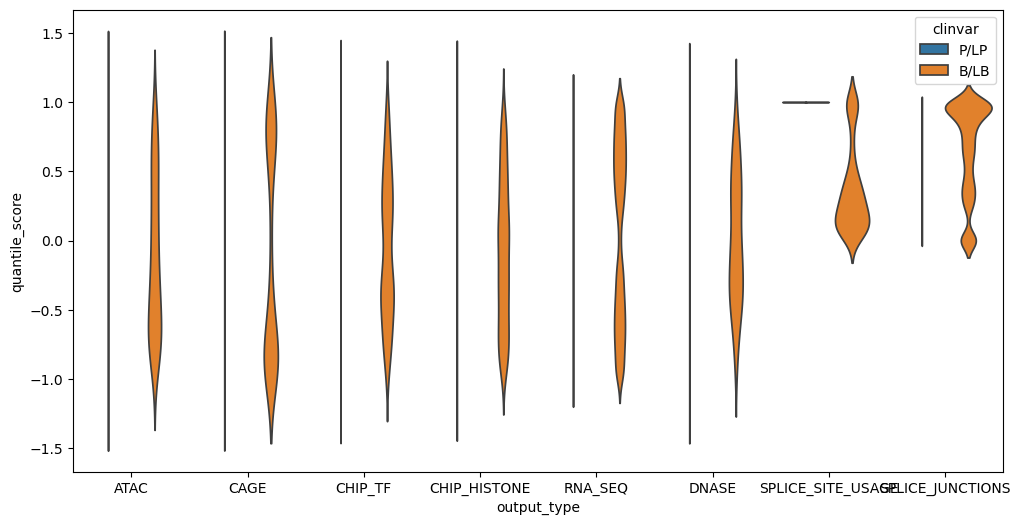

In [21]:
plt.figure(figsize=(12, 6))

sns.violinplot(data=all_vars_df, #[all_vars_df['clinvar'] == 'P/LP'], 
               x="output_type", 
               y="quantile_score", 
               hue='clinvar',
               inner=None,
               dodge = 'auto',
              # cut=0,
              # density_norm='width',
              # bw_method='silverman',
              gridsize=10000) #, split=True, gap=0.1) #, inner='point')

In [94]:
filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_HISTONE')]

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,raw_score,quantile_score,transcription_factor,histone_mark,gtex_tissue,clinvar
330,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,-0.019114,-0.865561,NaN,H3K27ac,NaN,P/LP
331,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K27me3,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,0.001607,0.237625,NaN,H3K27me3,NaN,P/LP
332,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K36me3,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,0.002797,0.485882,NaN,H3K36me3,NaN,P/LP
333,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,-0.009137,-0.830022,NaN,H3K4me1,NaN,P/LP
334,chr1:156114912:GCCGGCCATGGAGACC>G,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,-0.022978,-0.945557,NaN,H3K4me3,NaN,P/LP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,chr1:156138484:C>T,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K27me3,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,-0.002153,-0.392960,NaN,H3K27me3,NaN,B/LB
1986,chr1:156138484:C>T,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K36me3,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,0.000544,0.046111,NaN,H3K36me3,NaN,B/LB
1987,chr1:156138484:C>T,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,-0.002291,-0.494645,NaN,H3K4me1,NaN,B/LB
1988,chr1:156138484:C>T,chr1:155587039-156635615:.,NaN,NaN,NaN,NaN,NaN,NaN,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0002084 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,single,False,0.000000,0.023068,NaN,H3K4me3,NaN,B/LB


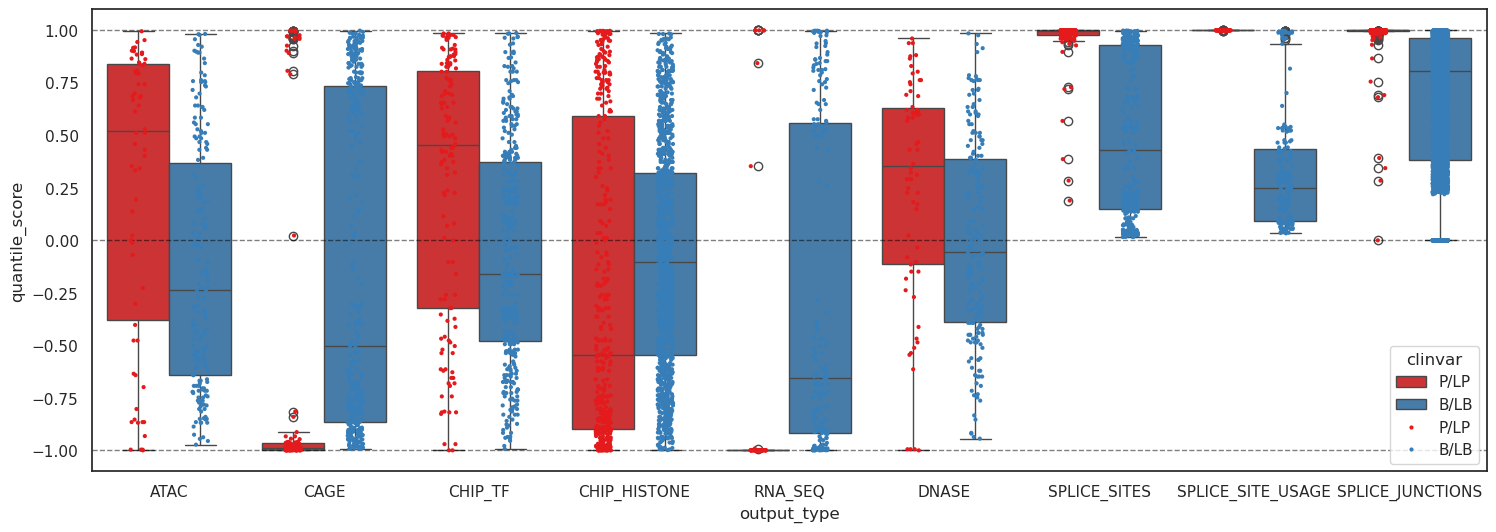

In [17]:
sns.set_theme(style="white", palette='Set1')

plt.figure(figsize=(18, 6))

# ax = sns.violinplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', split=True, gap=0.1) #, inner='point')

ax = sns.boxplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar') #, alpha=0.5) #, split=True, gap=0.1) #, inner='point')
sns.stripplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', size=3, dodge=True, ax=ax) 

# ax = sns.stripplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', size=3, dodge=True) # ax=ax, 

# sns.swarmplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', dodge=True, size=1, ax=ax) #, jitter=0.2)

ax.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=-1, color="black", linestyle="--", linewidth=1, alpha=0.5)
# plt.savefig("figs/clinvar_scores_box_strip.png", dpi=300, bbox_inches="tight")

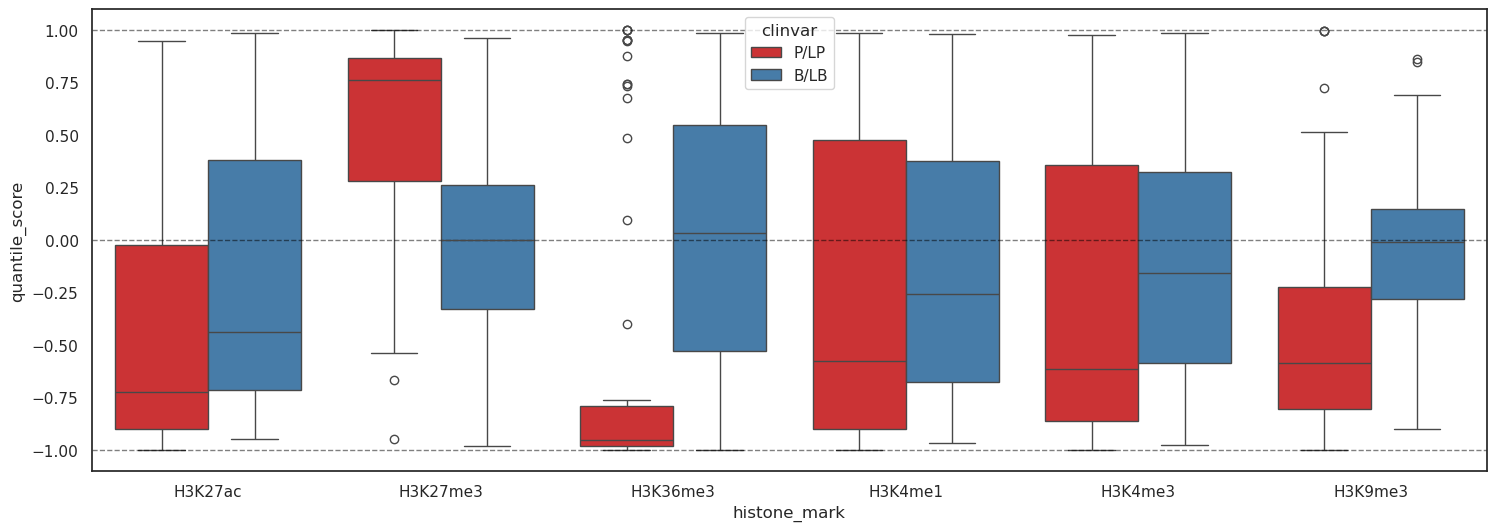

In [20]:
plt.figure(figsize=(18, 6))
# ax = sns.violinplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_HISTONE')], x="histone_mark", y="quantile_score", hue='clinvar', split=True, gap=0.1) #, inner='point')

ax = sns.boxplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_HISTONE')], x="histone_mark", y="quantile_score", hue='clinvar') #, alpha=0.5) #, split=True, gap=0.1) #, inner='point')
# sns.stripplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_HISTONE')], x="histone_mark", y="quantile_score", hue='clinvar', size=3, ax=ax, dodge=True)

# ax = sns.stripplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_HISTONE')], x="histone_mark", y="quantile_score", hue='clinvar', size=3, dodge=True) #, ax=ax, dodge=True)
# sns.swarmplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', dodge=True, size=1, ax=ax) #, jitter=0.2)

ax.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=-1, color="black", linestyle="--", linewidth=1, alpha=0.5)
# plt.savefig("figs/clinvar_scores_histones_box.png", dpi=300, bbox_inches="tight")

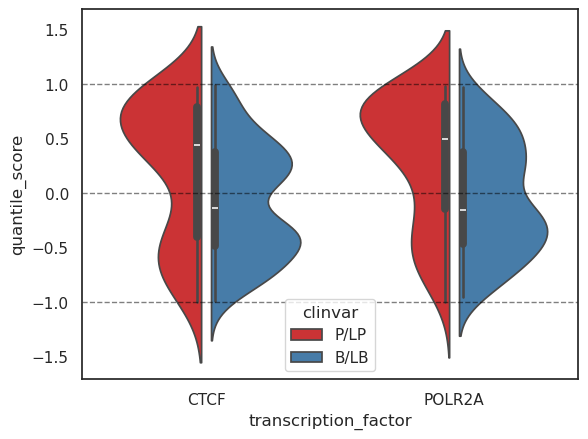

In [113]:
# plt.figure(figsize=(10, 6))
ax = sns.violinplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_TF')], x="transcription_factor", y="quantile_score", hue='clinvar', split=True, gap=0.1) #, inner='point')
# ax = sns.boxplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_TF')], x="transcription_factor", y="quantile_score", hue='clinvar') #, alpha=0.5) #, split=True, gap=0.1) #, inner='point')
# sns.stripplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'CHIP_TF')], x="transcription_factor", y="quantile_score", hue='clinvar', size=3, dodge=True, ax=ax) #, ax=ax, dodge=True)
# sns.swarmplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', dodge=True, size=1, ax=ax) #, jitter=0.2)

ax.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=-1, color="black", linestyle="--", linewidth=1, alpha=0.5)
# plt.savefig("figs/clinvar_scores_tfs_violin.png", dpi=300, bbox_inches="tight")

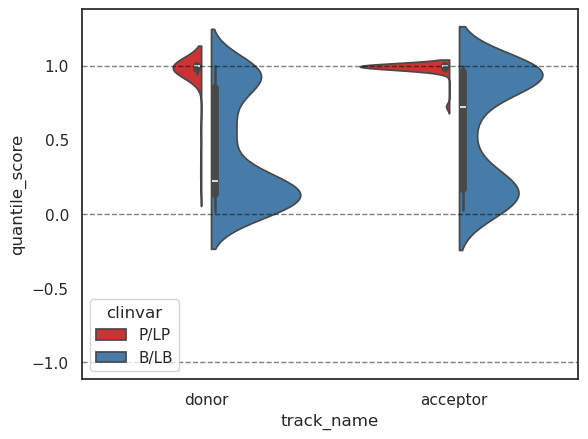

In [24]:
# plt.figure(figsize=(18, 6))
ax = sns.violinplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'SPLICE_SITES')], x="track_name", y="quantile_score", hue='clinvar', split=True, gap=0.1) #, inner='point')

# ax = sns.boxplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'SPLICE_SITES')], x="track_name", y="quantile_score", hue='clinvar') #, alpha=0.5) #, split=True, gap=0.1) #, inner='point')
# sns.stripplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'SPLICE_SITES')], x="track_name", y="quantile_score", hue='clinvar', size=3, ax=ax, dodge=True)

# ax = sns.stripplot(data=filt_vars_df[(filt_vars_df['output_type'] == 'SPLICE_SITES')], x="track_name", y="quantile_score", hue='clinvar', size=3, dodge=True) #, ax=ax, dodge=True)
# sns.swarmplot(data=filt_vars_df, x="output_type", y="quantile_score", hue='clinvar', dodge=True, size=1, ax=ax) #, jitter=0.2)

ax.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=-1, color="black", linestyle="--", linewidth=1, alpha=0.5)
plt.savefig("figs/clinvar_scores_splicesites_violin.png", dpi=300, bbox_inches="tight")

<Axes: xlabel='quantile_score', ylabel='Count'>

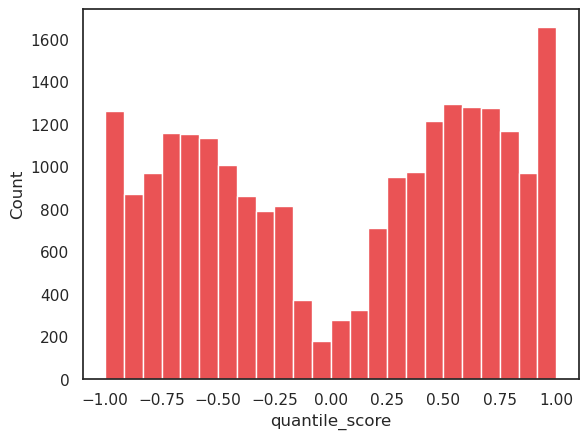

In [71]:
sns.histplot(data=all_vars_df[(all_vars_df['clinvar'] == 'B/LB') & (all_vars_df['output_type'] == 'RNA_SEQ')], x="quantile_score")

In [5]:
plp_df[(plp_df['ontology_curie'] == LV_UB)].output_type.unique()

array(['ATAC', 'CAGE', 'CHIP_TF', 'CHIP_HISTONE', 'RNA_SEQ', 'DNASE',
       'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS'], dtype=object)

In [7]:
blb_df.output_type.unique()

array(['ATAC', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'RNA_SEQ',
       'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS'], dtype=object)

In [8]:
print(len(blb_df))
blb_df = blb_df[blb_df.track_strand != '-']
print(len(blb_df))

print(len(plp_df))
plp_df = plp_df[plp_df.track_strand != '-']
print(len(plp_df))

30790
18651
16596
12570


In [9]:
blb_stats = blb_df.groupby('output_type')['quantile_score'].agg(['min', 'max', 'mean', 'median'])
print('B/LB variant score stats')
print(blb_stats)
print()
plp_stats = plp_df.groupby('output_type')['quantile_score'].agg(['min', 'max', 'mean', 'median'])
print('P/LP variant score stats')
print(plp_stats)

B/LB variant score stats
                        min       max      mean    median
output_type                                              
ATAC              -0.972998  0.982893 -0.132880 -0.237625
CAGE              -0.993622  0.989902 -0.113791 -0.485882
CHIP_HISTONE      -0.998918  0.985088 -0.090094 -0.103452
CHIP_TF           -0.993767  0.987586 -0.061449 -0.160114
DNASE             -0.944322  0.985426 -0.001718 -0.057616
RNA_SEQ           -0.999980  0.999980  0.061247  0.259272
SPLICE_JUNCTIONS   0.000010  0.999659  0.661224  0.806973
SPLICE_SITE_USAGE  0.026026  0.999059  0.360478  0.263730

P/LP variant score stats
                        min       max      mean    median
output_type                                              
ATAC              -0.999980  0.995687  0.251447  0.520285
CAGE              -0.999961  0.998471 -0.677132 -0.990995
CHIP_HISTONE      -0.999980  0.997737 -0.232795 -0.545117
CHIP_TF           -0.999950  0.985088  0.267397  0.454426
DNASE             -0.

In [33]:
# Top 1% by |quantile_score| within each output_type (extreme pos or neg)
q = 0.99

blb_abs = blb_df['quantile_score'].abs()
blb_thresh = blb_abs.groupby(blb_df['output_type']).transform('quantile', q=q)
blb_df_top1 = blb_df[blb_abs >= blb_thresh].copy().reset_index()

plp_abs = plp_df['quantile_score'].abs()
plp_thresh = plp_abs.groupby(plp_df['output_type']).transform('quantile', q=q)
plp_df_top1 = plp_df[plp_abs >= plp_thresh].copy().reset_index()

print(blb_df.groupby('output_type').size().rename('n_all').to_frame()
      .join(blb_df_top1.groupby('output_type').size().rename('n_top1%')))
print()
print(plp_df.groupby('output_type').size().rename('n_all').to_frame()
      .join(plp_df_top1.groupby('output_type').size().rename('n_top1%')))


                   n_all  n_top1%
output_type                      
ATAC                 199        2
CAGE                 199        2
CHIP_HISTONE        1194       12
CHIP_TF              398        4
DNASE                199        2
RNA_SEQ            10746      113
SPLICE_JUNCTIONS    5318       55
SPLICE_SITE_USAGE    398        4

                   n_all  n_top1%
output_type                      
ATAC                 132        2
CAGE                  66        1
CHIP_HISTONE         396        6
CHIP_TF              132        2
DNASE                 66        1
RNA_SEQ            11088      111
SPLICE_JUNCTIONS     558      223
SPLICE_SITE_USAGE    132      116


In [34]:
plp_df_top1[plp_df_top1['gene_name'] == 'LMNA'].sort_values(by=["variant_id"])

,index,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,raw_score,quantile_score,transcription_factor,histone_mark,gtex_tissue
236,8529,chr1:156115275:G>A,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156115242,156130616,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 total RNA-seq,.,total RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,6.859375,0.99999,NaN,NaN,NaN
235,8526,chr1:156115275:G>A,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156115288,156130616,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,6.351562,0.99999,NaN,NaN,NaN
234,8525,chr1:156115275:G>A,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156115274,156130616,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,5.539062,0.99999,NaN,NaN,NaN
237,8530,chr1:156115275:G>A,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156115274,156134402,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 total RNA-seq,.,total RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,4.468750,0.99999,NaN,NaN,NaN
118,8321,chr1:156115275:G>A,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,NaN,NaN,SPLICE_SITE_USAGE,GeneMaskSplicingScorer(requested_output=SPLICE...,usage_UBERON:0002084 total RNA-seq,+,total RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,0.991623,0.99999,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,9001,chr1:156139078:A>T,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156137743,156139081,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,4.515625,0.99999,NaN,NaN,NaN
451,8999,chr1:156139078:A>T,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156138757,156139088,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,6.394531,0.99999,NaN,NaN,NaN
450,8998,chr1:156139078:A>T,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156138757,156139081,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,7.066406,0.99999,NaN,NaN,NaN
454,9003,chr1:156139078:A>T,chr1:155587039-156635615:.,ENSG00000160789,LMNA,protein_coding,+,156138757,156139088,SPLICE_JUNCTIONS,SpliceJunctionScorer(),junction_UBERON:0002084 total RNA-seq,.,total RNA-seq,UBERON:0002084,heart left ventricle,tissue,adult,encode,NaN,NaN,6.839844,0.99999,NaN,NaN,NaN


## Visualize a single variant

Pick a row from the P/LP top 1% table, parse `variant_id` into chromosome/position/REF/ALT, score that variant with the API client, and plot predicted REF vs ALT tracks around the site.

In [40]:
# Returns the row as a Series
# max_row = plp_df.loc[plp_df[plp_df['gene_name'] == 'LMNA']['quantile_score'].idxmax()]
# max_row

row = plp_df_top1.iloc[452]
row 

index                                                         9001
variant_id                                      chr1:156139078:A>T
scored_interval                         chr1:155587039-156635615:.
gene_id                                            ENSG00000160789
gene_name                                                     LMNA
gene_type                                           protein_coding
gene_strand                                                      +
junction_Start                                           156137743
junction_End                                             156139081
output_type                                       SPLICE_JUNCTIONS
variant_scorer                              SpliceJunctionScorer()
track_name              junction_UBERON:0002084 polyA plus RNA-seq
track_strand                                                     .
Assay title                                     polyA plus RNA-seq
ontology_curie                                      UBERON:000

In [41]:
# terms = []
terms = row.variant_id.split(':')
variant_chromosome = terms[0]
variant_position = int(terms[1])
bp = terms[2].split('>')
print(bp)
variant_reference_bases = bp[0]
variant_alternate_bases = bp[1]
print(variant_position)


['A', 'T']
156139078


In [44]:
# @title Score variant { run: "auto" }
organism = 'human'  # @param ["human", "mouse"] {type:"string"}
organism_map = {
    'human': dna_client.Organism.HOMO_SAPIENS,
    'mouse': dna_client.Organism.MUS_MUSCULUS,
}
organism = organism_map[organism]

# @markdown Specify the variant:
# variant_chromosome = 'chr22'  # @param { type:"string" }
# variant_position = 36201698  # @param { type:"integer" }
# variant_reference_bases = 'A'  # @param { type:"string" }
# variant_alternate_bases = 'C'  # @param { type:"string" }



variant = genome.Variant(
    chromosome=variant_chromosome,
    position=variant_position,
    reference_bases=variant_reference_bases,
    alternate_bases=variant_alternate_bases,
)

# @markdown Specify length of sequence around variant to predict:
sequence_length = '100KB'  # @param ["2KB", "16KB", "100KB", "500KB", "1MB"] { type:"string" }
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{sequence_length}'
]

# The input interval is derived from the variant (centered on it).
interval = variant.LMNA_INTERVAL.resize(sequence_length)

# @markdown Additional settings:
variant_scores = model.score_variant(
    interval=interval,
    variant=variant,
    variant_scorers=selected_scorers,
)

df_scores = variant_scorers.tidy_scores(variant_scores)

download_predictions = False  # @param { type: "boolean" }
if download_predictions:
  df_scores.to_csv(f'{variant}_scores.csv', index=False)
  files.download(f'{variant}_scores.csv')

# @markdown Click `Filter` on the upper right hand side of the interactive dataframe and type a cell or tissue name like "brain" into the `Search by all fields box` to subset the variant scores to a specific tissue of interest:
columns = [
    c for c in df_scores.columns if c not in ['variant_id', 'scored_interval']
]
# df_scores[df_scores['ontology_curie' ] == LV_UB]
print("prediction finished")

prediction finished


Requested plot for output CONTACT_MAPS but no tracks exist in output. This is likely because this output does not exist for your ontologies or requested DNA strand.


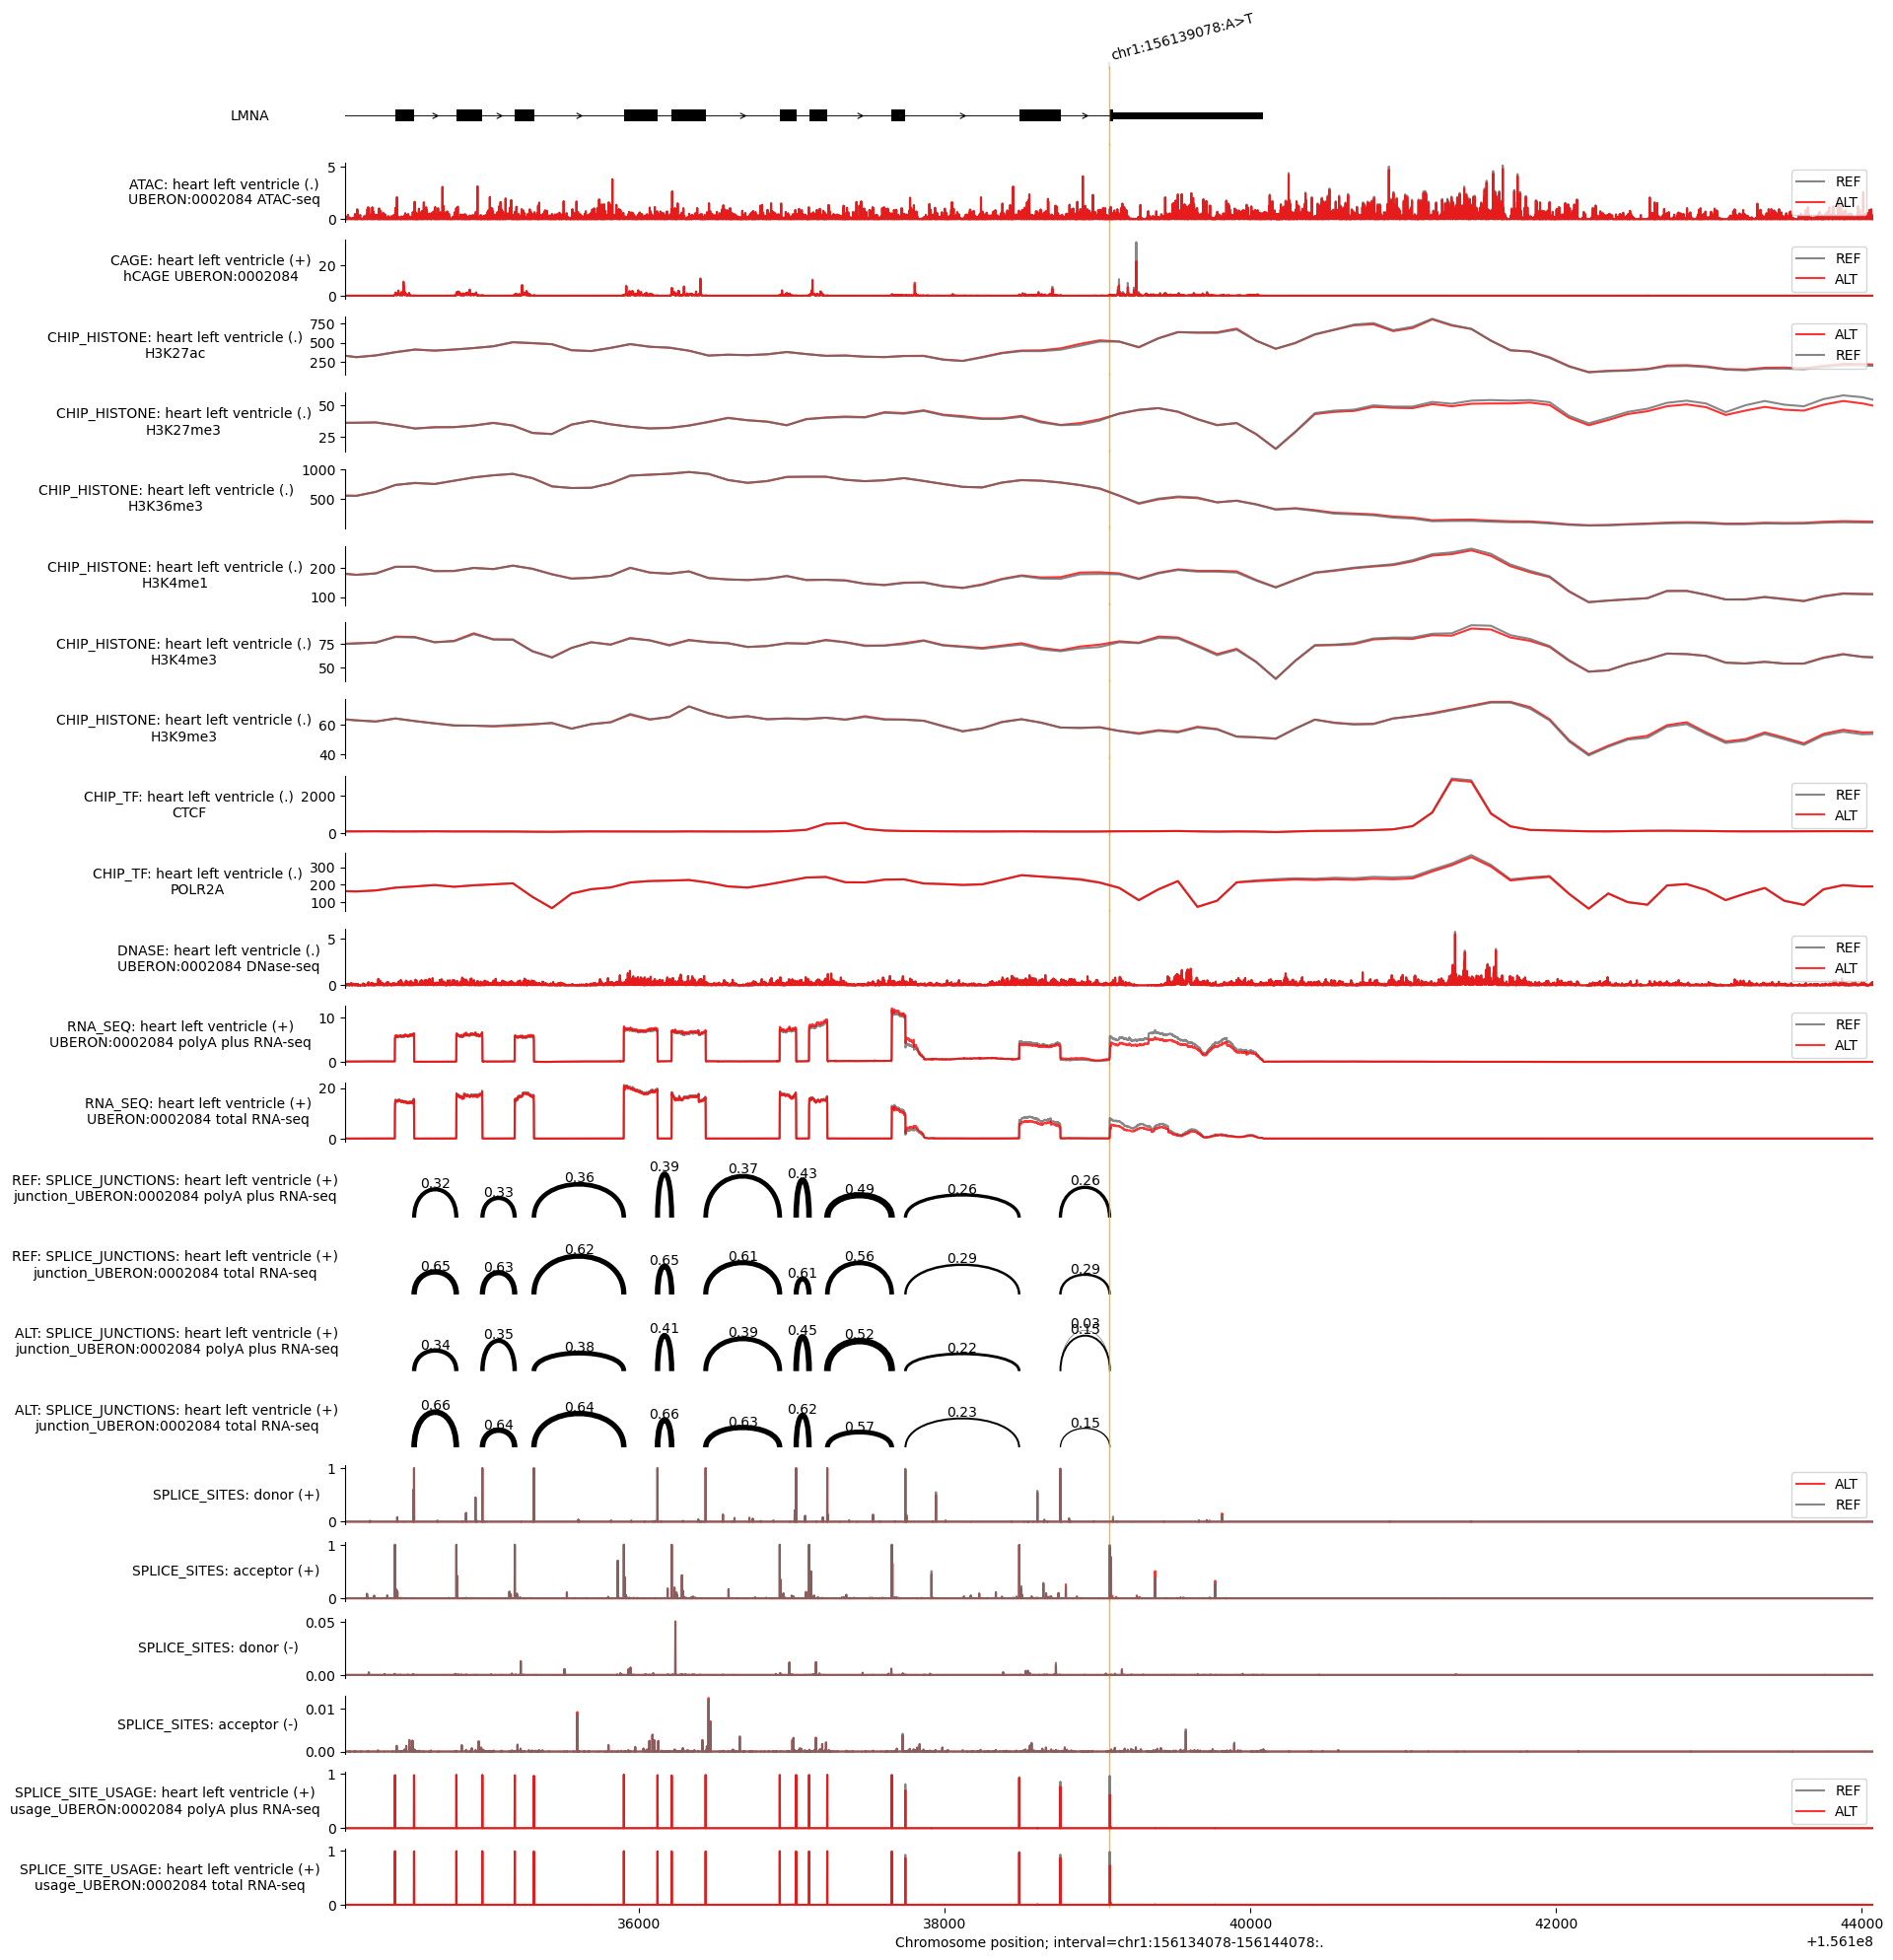

In [54]:
# Initialize an empty dictionary to serve as a variant effect prediction cache.
_prediction_cache = {}

_transcript_extractor_cache = {}


# @title Visualize variant effects { run: "auto" }
# @markdown We can also visualise the predicted effects of the variant by first predicting tracks for the REF and ALT alleles:

# @markdown Specify list of cell and tissue ontologies:
ontology_terms = [LV_UB]  # @param

# @markdown Gene and transcript annotation options:
plot_gene_annotation = True  # @param { type: "boolean" }
plot_longest_transcript_only = True  # @param { type: "boolean" }

# @markdown Output types to plot (if present in output):
plot_rna_seq = True  # @param { type: "boolean" }
plot_cage = True  # @param { type: "boolean" }
plot_atac = True  # @param { type: "boolean" }
plot_dnase = True  # @param { type: "boolean" }
plot_chip_histone = True  # @param { type: "boolean" }
plot_chip_tf = True  # @param { type: "boolean" }
plot_splice_sites = True  # @param { type: "boolean" }
plot_splice_site_usage = True  # @param { type: "boolean" }
plot_contact_maps = True  # @param { type: "boolean" }
plot_splice_junctions = True  # @param { type: "boolean" }

# @markdown Option to filter tracks to only a specific DNA strand:
filter_to_positive_strand = False  # @param { type: "boolean" }
filter_to_negative_strand = False  # @param { type: "boolean" }
if filter_to_positive_strand and filter_to_negative_strand:
  raise ValueError(
      'Cannot specify both filter_to_positive_strand and '
      'filter_to_negative_strand.'
  )

# @markdown Specify a list of Transription Factors to select from CHIP_TF outputs e.g. ['IKZF1'].
# These must be contained in the 'transcription_factor' column of the CHIP_TF metadata.
transcription_factors = None  # @param

# @markdown Other visualization options:
ref_color = 'dimgrey'  # @param { type: "string" }
alt_color = 'red'  # @param { type: "string" }
ref_alt_colors = {'REF': ref_color, 'ALT': alt_color}
plot_interval_width = 10000 # @param { type: "slider", min: 2048, max: 1048576, step: 2048}
plot_interval_shift = 0 # @param { type: "slider", min: -524288, max: 524288, step: 2048}


# Load gene annotation.
if organism in _transcript_extractor_cache:
  transcript_extractor, longest_transcript_extractor = (
      _transcript_extractor_cache[organism]
  )
else:
  match organism:
    case dna_client.Organism.HOMO_SAPIENS:
      gtf_path = HG38_GTF_PATH
    case dna_client.Organism.MUS_MUSCULUS:
      gtf_path = MM10_GTF_FEATHER
    case _:
      raise ValueError(f'Unsupported organism: {organism}')

  gtf = pd.read_feather(gtf_path)

  # Filter to protein-coding genes and highly supported transcripts.
  gtf_transcript = gene_annotation.filter_transcript_support_level(
      gene_annotation.filter_protein_coding(gtf), ['1']
  )

  # Extractor for identifying transcripts in a region.
  transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

  # Also define an extractor that fetches only the longest transcript per gene.
  gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
      gtf_transcript
  )
  longest_transcript_extractor = transcript.TranscriptExtractor(
      gtf_longest_transcript
  )
  _transcript_extractor_cache[organism] = (
      transcript_extractor,
      longest_transcript_extractor,
  )


def _predict_variant_cached(
    interval, variant, organism, requested_outputs, ontology_terms
):
  """Cache wrapper of dna_model.predict_variant."""
  # Create a unique key from the function arguments.
  cache_key = (
      str(interval),
      str(variant),
      str(organism),
      tuple(requested_outputs),
      tuple(ontology_terms),
  )

  # Check if the result is already in the cache.
  if cache_key in _prediction_cache:
    return _prediction_cache[cache_key]

  # If not, compute the prediction and store it in the cache.
  result = model.predict_variant(
      interval=interval,
      variant=variant,
      organism=organism,
      requested_outputs=requested_outputs,
      ontology_terms=ontology_terms,
  )
  _prediction_cache[cache_key] = result
  return result


output = _predict_variant_cached(
    interval=interval,
    variant=variant,
    organism=organism,
    requested_outputs=[*dna_client.OutputType],
    ontology_terms=ontology_terms,
)

# Filter to DNA strand if requested.
ref, alt = output.reference, output.alternate

if filter_to_positive_strand:
  ref = ref.filter_to_nonnegative_strand()
  alt = alt.filter_to_nonnegative_strand()
elif filter_to_negative_strand:
  ref = ref.filter_to_strand(strand='-')
  alt = alt.filter_to_strand(strand='-')

# Function to filter to TFs if requested.


def _maybe_filter_to_tfs(
    tdata: track_data.TrackData,
) -> track_data.TrackData | None:
  if not plot_chip_tf:
    return tdata

  if plot_chip_tf and (transcription_factors is not None):
    if not isinstance(transcription_factors, list):
      raise ValueError('TFs must be input as a list of strings.')
    if not isinstance(transcription_factors[0], str):
      raise ValueError('TFs must be input as a list of strings.')

  if transcription_factors is None:
    return tdata

  tf_rows = tdata.metadata.index[
      tdata.metadata['transcription_factor'].isin(transcription_factors)
  ]
  if not tf_rows.any():
    print(
        f'No tracks found for specified transcription factors and'
        f' ontology_terms.'
    )
    return None
  missing_tfs = set(transcription_factors).difference(
      set(tdata.metadata['transcription_factor'])
  )
  if missing_tfs:
    print(
        f'Could not find tracks in chip_tf outputs corresponding to the'
        f' following requested TFs'
    )
  return tdata.select_tracks_by_index(tf_rows)


# Build plot.
components = []

# Gene and transcript annotation.
if plot_gene_annotation:
  if plot_longest_transcript_only:
    transcripts = longest_transcript_extractor.extract(interval)
  else:
    transcripts = transcript_extractor.extract(interval)
  components.append(plot_components.TranscriptAnnotation(transcripts))


# Individual output type plots.
plot_map = {
    'plot_atac': (ref.atac, alt.atac, 'ATAC'),
    'plot_cage': (ref.cage.filter_to_nonnegative_strand(), alt.cage.filter_to_nonnegative_strand(), 'CAGE'),
    'plot_chip_histone': (ref.chip_histone, alt.chip_histone, 'CHIP_HISTONE'),
    'plot_chip_tf': (
        _maybe_filter_to_tfs(ref.chip_tf),
        _maybe_filter_to_tfs(alt.chip_tf),
        'CHIP_TF',
    ),
    'plot_contact_maps': (ref.contact_maps, alt.contact_maps, 'CONTACT_MAPS'),
    'plot_dnase': (ref.dnase, alt.dnase, 'DNASE'),
    'plot_rna_seq': (ref.rna_seq.filter_to_nonnegative_strand(), alt.rna_seq.filter_to_nonnegative_strand(), 'RNA_SEQ'),
    'plot_splice_junctions': (
        ref.splice_junctions.filter_to_strand('+'),
        alt.splice_junctions.filter_to_strand('+'),
        'SPLICE_JUNCTIONS',
    ),
    'plot_splice_sites': (ref.splice_sites, alt.splice_sites, 'SPLICE_SITES'),
    'plot_splice_site_usage': (
        ref.splice_site_usage.filter_to_nonnegative_strand(),
        alt.splice_site_usage.filter_to_nonnegative_strand(),
        'SPLICE_SITE_USAGE',
    ),
}

for key, (ref_data, alt_data, output_type) in plot_map.items():
  if eval(key) and ref_data is not None and ref_data.values.shape[-1] == 0:
    print(
        f'Requested plot for output {output_type} but no tracks exist in'
        ' output. This is likely because this output does not exist for your'
        ' ontologies or requested DNA strand.'
    )
  if eval(key) and ref_data and alt_data:
    match output_type:
      case 'CHIP_HISTONE':
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{histone_mark}}'
        )
      case 'CHIP_TF':
        ylabel_template = (
            f'{output_type}: {{biosample_name}}'
            ' ({strand})\n{transcription_factor}'
        )
      case 'CONTACT_MAPS':
        ylabel_template = f'{output_type}: {{biosample_name}} ({{strand}})'
      case 'SPLICE_SITES':
        ylabel_template = f'{output_type}: {{name}} ({{strand}})'
      case _:
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{name}}'
        )

    if output_type == 'CONTACT_MAPS':
      component = plot_components.ContactMapsDiff(
          tdata=alt_data - ref_data,
          ylabel_template=ylabel_template,
      )
      components.append(component)
    elif output_type == 'SPLICE_JUNCTIONS':
      ref_plot = plot_components.Sashimi(
          ref_data,
          ylabel_template='REF: ' + ylabel_template,
      )
      alt_plot = plot_components.Sashimi(
          alt_data,
          ylabel_template='ALT: ' + ylabel_template,
      )
      components.extend([ref_plot, alt_plot])
    else:
      component = plot_components.OverlaidTracks(
          tdata={'REF': ref_data, 'ALT': alt_data},
          colors=ref_alt_colors,
          ylabel_template=ylabel_template,
      )
      components.append(component)

if plot_interval_width > interval.width:
  raise ValueError(
      f'plot_interval_width ({plot_interval_width}) must be less than '
      f'interval.width ({interval.width}).'
  )

plot = plot_components.plot(
    components=components,
    interval=interval.shift(plot_interval_shift).resize(plot_interval_width),
    annotations=[
        plot_components.VariantAnnotation([variant]),
    ],
)

In [ ]:
# # Score variants in the VCF file.
# results = []

# for i, vcf_row in tqdm(vcf.iterrows(), total=len(vcf)):
#   variant = genome.Variant(
#       chromosome=str(vcf_row.CHROM),
#       position=int(vcf_row.POS),
#       reference_bases=vcf_row.REF,
#       alternate_bases=vcf_row.ALT,
#       name=vcf_row.ID,
#   )
#   interval = variant.reference_interval.resize(sequence_length)

#   variant_scores = model.score_variant(
#       interval=interval,
#       variant=variant,
#       variant_scorers=selected_scorers,
#       organism=organism,
#   )
#   results.append(variant_scores)

# df_scores = variant_scorers.tidy_scores(results)


# # @markdown Other settings:
# download_predictions = True  # @param { type: "boolean" }

# if download_predictions:
#   df_scores.to_csv(f'{BASE_PATH}ag/variant-effects/osc/outputs/lmna_variants_pathogenic_VUS_LMNA.scores.csv', index=False)
# #   files.download('variant_scores.csv')

# df_scores

In [ ]:
# df_scores.to_pickle('lmna_pathogenic_variant_scores.pkl')
# # @markdown Other settings:
# download_predictions = True  # @param { type: "boolean" }

# if download_predictions:
#   df_scores.to_csv('/Users/coraalbers/Documents/BSGP/Lancaster_rotation/data/lmna_variant_scores.csv', index=False)
#   # files.download('/Users/coraalbers/Documents/BSGP/Lancaster_rotation/data/lmna_variant_scores.csv')

## Heart-filtered score export

Leftover cells from an earlier workflow: filter `df_scores` to heart (`UBERON:0000948`) and write a CSV. This uses in-memory batch-scoring results, not the ClinVar P/LP vs B/LB tables above, and the output path is a local Mac directory.

In [ ]:
columns = [c for c in df_scores.columns if c != 'ontology_curie']
heart_df_scores = df_scores[(df_scores['ontology_curie'] == 'UBERON:0000948')][columns] # heart uberon identifier
heart_df_scores.to_csv('/Users/coraalbers/Documents/BSGP/Lancaster_rotation/data/lmna_variant_scores_heart_UBERON0000948.csv', index=False)

In [18]:
heart_df_scores.head()

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,transcription_factor,histone_mark,gtex_tissue,raw_score,quantile_score
387,chr1:156114693:C>T,chr1:156049157-156180229:.,None,None,None,None,None,None,DNASE,"CenterMaskScorer(requested_output=DNASE, width...",UBERON:0000948 DNase-seq,.,DNase-seq,heart,tissue,embryonic,encode,paired,False,NaN,NaN,NaN,0.141282,0.963955
2883,chr1:156114693:C>T,chr1:156049157-156180229:.,None,None,None,None,None,None,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0000948 Histone ChIP-seq H3K27me3,.,Histone ChIP-seq,heart,tissue,embryonic,encode,single,False,NaN,H3K27me3,NaN,-0.177345,-0.999621
2884,chr1:156114693:C>T,chr1:156049157-156180229:.,None,None,None,None,None,None,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0000948 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,heart,tissue,embryonic,encode,single,False,NaN,H3K4me1,NaN,-0.000861,-0.134700
2885,chr1:156114693:C>T,chr1:156049157-156180229:.,None,None,None,None,None,None,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0000948 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,heart,tissue,embryonic,encode,single,False,NaN,H3K4me3,NaN,0.088124,0.988467
2886,chr1:156114693:C>T,chr1:156049157-156180229:.,None,None,None,None,None,None,CHIP_HISTONE,CenterMaskScorer(requested_output=CHIP_HISTONE...,UBERON:0000948 Histone ChIP-seq H3K9ac,.,Histone ChIP-seq,heart,tissue,embryonic,encode,single,False,NaN,H3K9ac,NaN,0.101405,0.989576
